## A lot of long distance Good Luck

Currently, when I am writing this, it is a global pandemic situation all over the world, with a newly infectious disease caused by a newly discovered coronavirus, called COVID-19. According to the website to [WHO (World Health Organization)](https://www.who.int/health-topics/coronavirus), most people infected with the COVID-19 virus will experience mild to moderate respiratory illness and recover without requiring special treatment.  Older people, and those with underlying medical problems like cardiovascular disease, diabetes, chronic respiratory disease, and cancer are more likely to develop serious illness.

Currently, as I am writing this, there are about 13 thousands people we have lost to the adverse effect of the disease, and more than three hundred thousands persons currently fighting against this disease, which rapidly grew out of China just within last three to four months. People are currently comparing it to the [Spanish flu](https://en.wikipedia.org/wiki/Spanish_flu), which took place roughly $100$ years before, and hence, almost none of us have any experience of dealing with a pandemic at such a large scale. As a countermeasure to reduce the spread of infectious disease, my hometown is at a Shelter-in-place lockdown, and hence I have almost nothing to do except scrapping through the internet to learn some new things that interests me.

However, I sincerely wish you all to stay unite, and stay safe. We would get through the hard times.

**WHO Guidelines to STAY SAFE:**

- The best way to prevent and slow down transmission is be well informed about the COVID-19 virus, the disease it causes and how it spreads. 
- Wash your hands frequently with an alcohol based rub or soap.
- Maintain social distancing.
- Avoid touching eyes, nose and mouth.
- Practice respiratory hygiene.
- If you have fever, cough and difficulty breathing, seek medical care early.
- Stay informed and follow advice given by your healthcare provider.
- Protect yourselves and protect others.

## Introduction

Now, as you have quite guessed from the title of the post, this is about segmenting an image about different regions. Image Segmentation refers to the task that is used to seperate foreground from the background of an image. Before understanding what it means, note that, an image can be described as a collection of geometric shapes (lines, curves, polygons etc.) having various aesthestics mapping to real life (or fictional) quantities or objects. I find it essentially similar to that of `ggplot` plotting technique, we have a dataset comprising of some measurements or objects which we want to measure, and we can build a plot (read an image) out of it, by creating an aesthestic mapping of those measurements to geometric objects such as points, lines, curves, polygons etc. The book written by Leland Wilkinson named [**The Grammar of Graphics**](https://books.google.co.in/books/about/The_Grammar_of_Graphics.html?id=ZiwLCAAAQBAJ&source=kp_book_description&redir_esc=y) is one such book which describes the process in great detail.

Let me start with an example. Let's say you have an image of a red chair, with a white wall at the back. Now, when you look at the image, you are seeing possibly some polygons (which may have some curved edges), which defines different regions of a chair, each having a slightly different shade of colour, due to disparate reflective nature and absorption of photons when there is a lighting source used to illuminate the scene. Now, in simple terms, there is a latent dataset with rich measurements of different characteristics of the objects in the scene (namely the chair and the wall), namely containing the spatial and lighting informations, however we do not get to observe that.

| x coordinate | y coordinate | z coordinate | colour(rgb)   |
|--------------|--------------|--------------|---------------|
| 2.2123       | 23.443       | 0. 1768      | (240, 75, 90) |
| ...          | ...          | ...          | ...           |


Now, an image can also be described as a mapping of the above rows to a rows like this (which is observable by means of the image at hand),

| x coordinate | y coordinate | colour(rgb)   |
|--------------|--------------|---------------|
| 23           | 35           | (240, 75, 90) |
| ...          | ...          | ...           |

where the new x and y coordinates are coordinates in the 2-dimensional map described by the plane of the image. Now, to each of the rows of the latent dataset, we associated an object (because that is how we interprete it), for instance, the rows which consitute the 3-dimensional spatial coordinates of the location of atoms of the chiar, are associated with the chair, and the rest, maybe associated with the floor and the white wall. Image segmentation specifically refers to generating that interpretation in a systematic and automatic way, just by looking at the visual sensory information (i.e. the 2nd type of dataset), and the problem is difficult, as the mapping by which the latent dataset converted to this, is extremely complicated in nature (maybe unknown). Therefore, a perfect image segmentation achieves the hidden representation of an image into something that is more meaningful and easier to analyze.

## Importing Necessary Python Packages

For this, we shall be using `numpy` for vector and matrix manipulations, `cv2`to read image files as a numpy array, and finally `matplotlib` for various plotting related tasks. I am using python 3.7.4 for this.

*Note: If you want to know an image can be represented in an array (or a tensor), go check out the section on "Making some utlity functions" on my other post on [Texture Networks](https://subroy13.github.io/post/post3/)*

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.version

'3.7.4 (default, Aug  9 2019, 18:34:13) [MSC v.1915 64 bit (AMD64)]'

In [6]:
import warnings
warnings.simplefilter('ignore')

I shall be using the beautiful picture of [Mona Lisa](https://en.wikipedia.org/wiki/Mona_Lisa) by Leaonardo Da Vinci. I am not a connoisseur about aesthestics, but I appreciate the image from the point of view that it has a subject, and a background, two very clearly seperated item in the image.

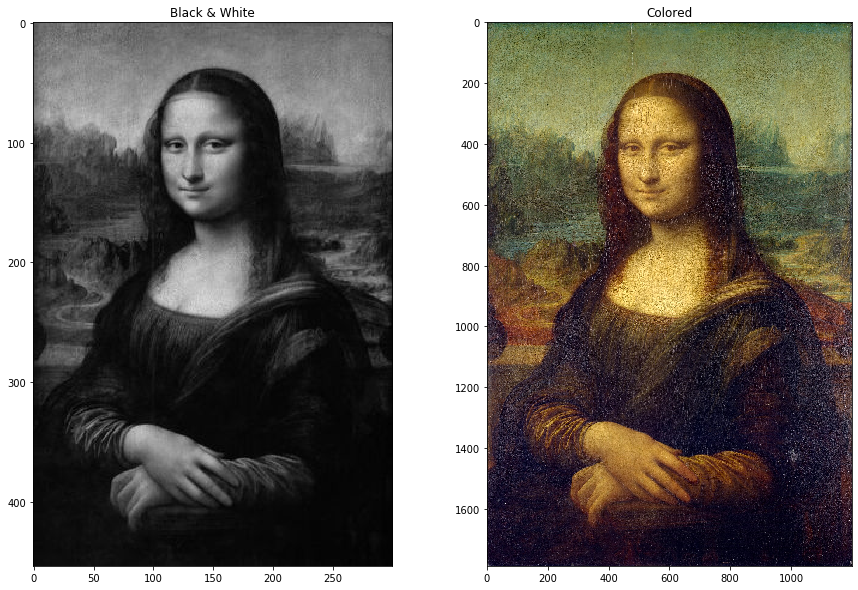

In [2]:
bw_img = cv2.imread('./Mona_Lisa.jpg')  # read a black and white version
col_img = cv2.imread('./Mona_Lisa_color.jpg')   # and a color version

# since, cv2 reads in BGR format, we need to use RGB format for plotting
col_img = cv2.cvtColor(col_img, cv2.COLOR_BGR2RGB)

fig, plots = plt.subplots(1,2, figsize = (15, 10))     # subplot with 1 row, 2 columns

# subplot 1
plots[0].imshow(bw_img, cmap='gray')
plots[0].set_title('Black & White')

# subplot 2
plots[1].imshow(col_img)
plots[1].set_title('Colored')
plt.show()

## Histogram Thresholding

Histogram thresholding is the most basic way of segmenting an image. It is fast, simple yet very effective. For instance, assume we have a grayscale image, where the foreground and background has different grayscale intensities. Let us say, we have the grayscale intensity $i$ ($0 \leq i \leq 255$), appearing $f_i$ times in the image (i.e. there are $f_i$ pixels with grayscale intensity level $i$), and $N$ is the total number of digital pixels in the image. Now, assume that, the background object has a mean intensity level $\mu_b$, and foreground has mean intensity level $\mu_f$. Then, we assume, 

$$
i_{x, y} \sim 
\begin{cases}
g(i_{x, y}; \mu_f) & \text{if (x, y) pixel belongs to foreground} \\
g(i_{x, y}; \mu_b) & \text{if (x, y) pixel belongs to background} \\
\end{cases}
$$

where $i_{x, y}$ is the intensity level at (x, y)-th pixel of the image, which is a random variable and follows a density $g(\cdot)$ whose location is specified by $\mu_f$ or $\mu_b$, based on whether the pixel corresponds to background object (the white wall) or the foreground object (the red chair).

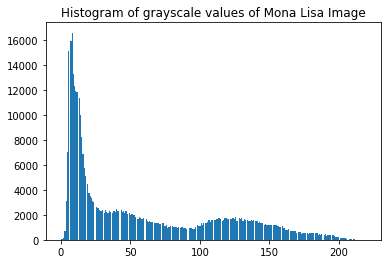

In [3]:
plt.hist(bw_img.ravel(), bins = 255)
plt.title('Histogram of grayscale values of Mona Lisa Image')
plt.show()

As you can see, there are 3 clear regions in the histogram, which might indicates, there are 3 such segments possible, since it looks like the histogram comprises of mixture of 3 random variables.

1. First component has a mean about at 5.
2. Second component shows a mode (or peak) about at 45.
3. Third component shows a mode at 130.

So, we consider some thresholds, at 25 and 95. Now, we shall simply use these thresholds, and assign different values to all pixel intensities that are smaller than 25 to one value, all in between 25 and 95 to another value, and all pixels higher than 95 to another value. This should give us some possible segmentation, although not automatic, but is useful to gain insights and idea about the method.

The following function performs the segmentation given the values of the thresholds.

In [4]:
def segment(img, thresholds):
    bins = [0]    # these are used to binning the image
    for i in range(len(thresholds)):
        bins.append( thresholds[i] )
    bins.append(256)
    
    img = np.array(img)
    bins = np.array(bins)
    segment_bin = np.digitize(img, bins)
    return(bins[segment_bin] )    # return the segmented image"

Now we apply the threshold 25, 95 and both to see which regions are being identified as foreground and backgrund for which thresholds.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


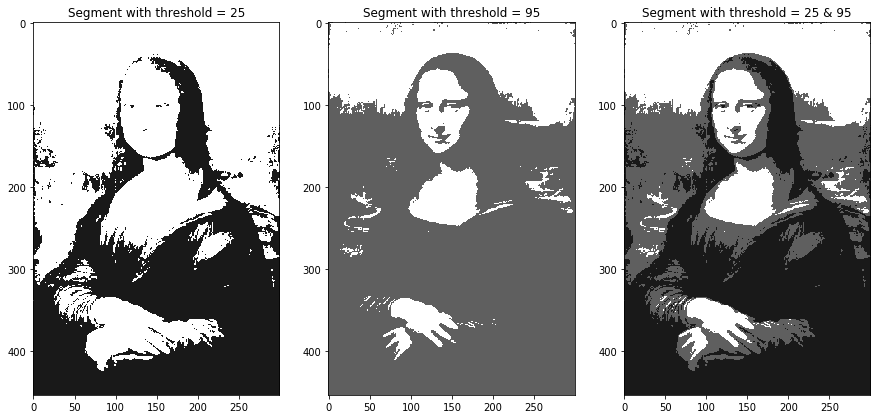

In [9]:
thres1 = [25]
thres2 = [95]
thres3 = [25, 95]

fig, plots = plt.subplots(1,3, figsize = (15, 10))     # subplot with 1 row, 3 columns

# subplot 1
plots[0].imshow(segment(bw_img, thres1), cmap='gray')
plots[0].set_title('Segment with threshold = 25')

# subplot 2
plots[1].imshow(segment(bw_img, thres2), cmap='gray')
plots[1].set_title('Segment with threshold = 95')

# subplot 3
plots[2].imshow(segment(bw_img, thres3), cmap='gray')
plots[2].set_title('Segment with threshold = 25 & 95')

plt.show()

It seems that, the threshold at 25 separates the clothings and darker shades of skin of Mona Lisa from the background, while threshold at 95 tend to separate the lighter shades of skin (the face, the hands). Combining both yields a good understanding of the different segments available in the image.

Now, let us perform similar analysis on the coloured version of the image. In that case, we process each of the channel seperately through this procedure.

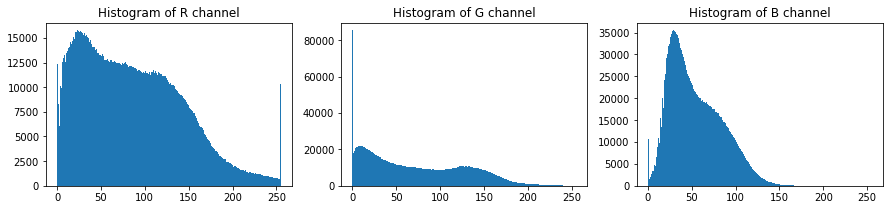

In [9]:
fig, plots = plt.subplots(1,3, figsize = (15, 3))     # subplot with 1 row, 3 columns

# subplot 1
plots[0].hist(col_img[:,:,0].ravel(), bins = 255)
plots[0].set_title('Histogram of R channel')

# subplot 2
plots[1].hist(col_img[:,:,1].ravel(), bins = 255)
plots[1].set_title('Histogram of G channel')

# subplot 3
plots[2].hist(col_img[:,:,2].ravel(), bins = 255)
plots[2].set_title('Histogram of B channel')

plt.show()

Now, it seems a lot more difficult to separate background from foreground on the basis of thresholds just by subjectively judging them.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


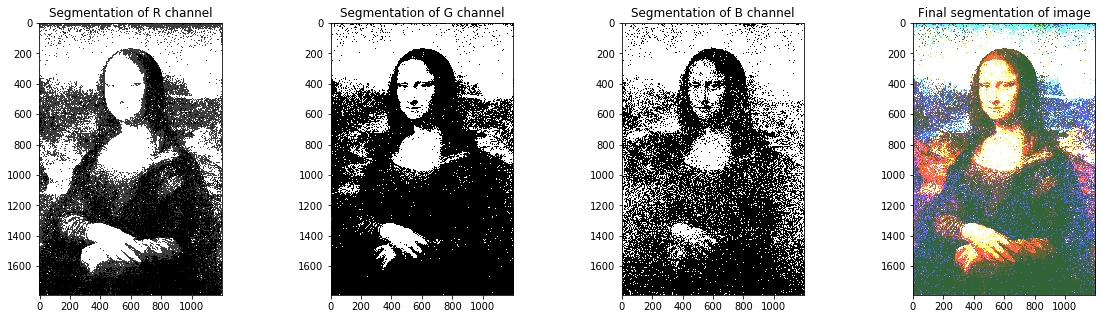

In [71]:
thres_R = [50, 100]
thres_G = [100]
thres_B = [55]

segment_R = np.expand_dims( segment(col_img[:, :, 0], thres_R) , 2)    # apply segmentation and convert to 3d array
segment_G = np.expand_dims( segment(col_img[:, :, 1], thres_G) , 2)
segment_B = np.expand_dims( segment(col_img[:, :, 2], thres_B) , 2)

segment_img = np.concatenate( (segment_R, segment_G, segment_B), axis = 2)


fig, plots = plt.subplots(1,4, figsize = (20, 5))     # subplot with 1 row, 4 columns

# subplot 1
plots[0].imshow(segment_R[:, :, 0], cmap = 'gray')
plots[0].set_title('Segmentation of R channel')

# subplot 2
plots[1].imshow(segment_G[:, :, 0], cmap = 'gray')
plots[1].set_title('Segmentation of G channel')

# subplot 3
plots[2].imshow(segment_B[:, :, 0], cmap = 'gray')
plots[2].set_title('Segmentation of B channel')

# final image
plots[3].imshow(segment_img)
plots[3].set_title('Final segmentation of image')

plt.show()

Therefore, we see that most the segmentation generally comes from the G channel itself, but the final segmentation does not look very promising. As you can see, there are lots of artifacts and noises all around. Therefore, we need our workaround against this, which we shall be discussing shortly.

## Otsu's Method

Otsu's method is a automatic way of detecting such thresholds. To better understand it, consider a threshold value $s$. Then, the best estimate of $\mu_f$ and $\mu_b$ are as follows:

$$
\begin{align}
\mu_b^{(s)} & = \dfrac{\sum_{i = 0}^{s} i f_i }{\sum_{i = 0}^{s} f_i}\\
\mu_f^{(s)} & = \dfrac{\sum_{i = (s+1)}^{255} i f_i }{\sum_{i = (s+1)}^{255} f_i}\\
\end{align}
$$

where the superscript is used to denote the threshold $s$.

Assuming that, foreground has higher lower intensity level than the foreground (or object) due to the fact that object is properly illuminated, one way to choose the threshold that minimizes the weighted intraclass variance, or conversely maximize the weighted interclass variance. Now, the formula of weighted interclass variance is simply;

$$V = \dfrac{{\sum_{i = 0}^{s} f_i}}{N} \times \dfrac{{\sum_{i = 0}^{s} f_i}}{N} \times \left[ \mu_b^{(s)}  - \mu_f^{(s)}\right]^2$$

The following function computes this interclass variance for all threshold levels $s = 1, 2, \dots 254$.

In [11]:
def interclass_var(img):
    var = np.zeros(256)
    freq = np.zeros(256)
    
    # obtain f_i's
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            freq[img[i, j]] += 1     # increase corresponding intensity frequency
            
    for s in range(1, 255):
        w1 = freq[0:s].sum()
        w2 = freq[s:].sum()
        if w1!=0 and w2!= 0:
            mu1 = sum( np.arange(s) * freq[0:s] ) / w1
            mu2 = sum( np.arange(s, 256) * freq[s:] ) / w2
            var[s] = w1 * w2 * ((mu1 - mu2)**2)
    
    return var

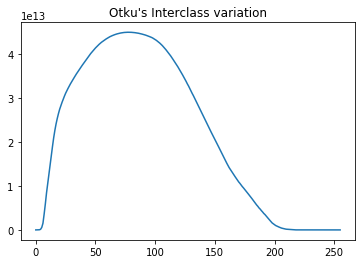

In [12]:
var = interclass_var(bw_img)
plt.plot(var)
plt.title("Otku's Interclass variation")
plt.show()

In [13]:
np.argmax(var)

78

It seems that 78 is the proper threshold where the interclass variance is maximized. So, let us take a look how the segmentation is for only one threshold equal to 78.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


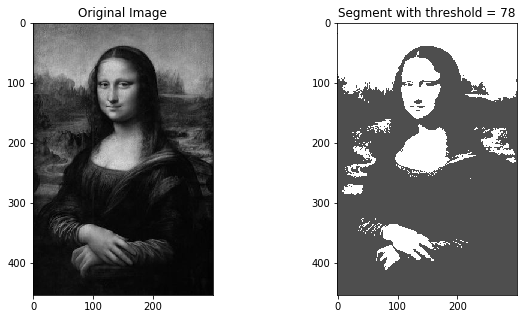

In [14]:
thres = [78]

fig, plots = plt.subplots(1,2, figsize = (10, 5))     # subplot with 1 row, 2 columns

# subplot 1
plots[0].imshow(bw_img, cmap='gray')
plots[0].set_title('Original Image')

# subplot 2
plots[1].imshow(segment(bw_img, thres), cmap='gray')
plots[1].set_title('Segment with threshold = 78')

plt.show()

We see that, the segmentation looks pretty good for just two shades of gray. However, it would have been better if the background was given a different shade from [Lisa del Giocondo](https://en.wikipedia.org/wiki/Lisa_del_Giocondo), the possible model for Mona Lisa. However, since in the original picture, they both have similar shades of gray, we cannot do it just based on the histogram of colour intensities. So, we need to account for spatial information as well.

Let us see, how much this automatic thresholding give us in the colour image of Mona Lisa.

In [56]:
var_r = interclass_var(col_img[:, :, 0])
var_g = interclass_var(col_img[:, :, 1])
var_b = interclass_var(col_img[:, :, 2])

print('Threshold for R channel', np.argmax(var_r))
print('Threshold for G channel', np.argmax(var_g))
print('Threshold for B channel', np.argmax(var_b))

Threshold for R channel 94
Threshold for G channel 82
Threshold for B channel 61


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


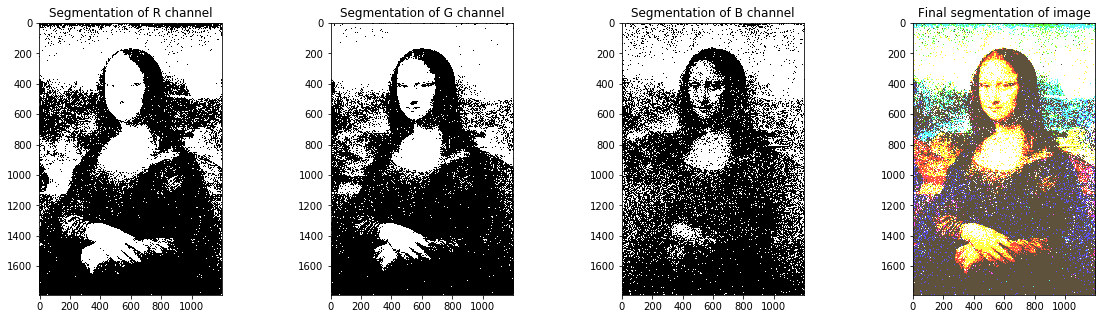

In [57]:
# Exactly same code as before
thres_R = [94]
thres_G = [82]
thres_B = [61]

segment_R = np.expand_dims( segment(col_img[:, :, 0], thres_R) , 2)    # apply segmentation and convert to 3d array
segment_G = np.expand_dims( segment(col_img[:, :, 1], thres_G) , 2)
segment_B = np.expand_dims( segment(col_img[:, :, 2], thres_B) , 2)

segment_img = np.concatenate( (segment_R, segment_G, segment_B), axis = 2)

fig, plots = plt.subplots(1,4, figsize = (20, 5))     # subplot with 1 row, 4 columns

# subplot 1
plots[0].imshow(segment_R[:, :, 0], cmap = 'gray')
plots[0].set_title('Segmentation of R channel')

# subplot 2
plots[1].imshow(segment_G[:, :, 0], cmap = 'gray')
plots[1].set_title('Segmentation of G channel')

# subplot 3
plots[2].imshow(segment_B[:, :, 0], cmap = 'gray')
plots[2].set_title('Segmentation of B channel')

# final image
plots[3].imshow(segment_img)
plots[3].set_title('Final segmentation of image')

plt.show()

The final segmentation clearly segments all the regions, like background and the model. However, it is extremely noisy. So, otsu's automatic thresholding does not perform any better for colour images.

## Incorporating Spatial Information: Co-occurence Matrix

To incorporate spatial information, as well as consider the intensity values of the image, there is a popular notion of Co-occurence matrix. As the name suggests, it captures how many times two intensity levels $i$ and $j$ appear spatially together in the image, and put that frequency in $(i, j)$-th cell of the matrix.

For example, the $(a, b)$-th entry of the co-occurence matrix is the frequency of the number of times, when $a$ appears at a pixel location of the image, and the color $b$ appears at the specified offset from that pixel locations. Now, if the offset is set to be $(1, 0)$, then it means the number of times the pixel intensities $(a, b)$ appear side by side horizontally in this order is given by the $(a, b)$-th element of the co-occurence matrix.

So, let us create a function which computes the co-occurence matrix for us.

In [15]:
# Create co-occurence matrix
def CCM(img, offset):
    comat = np.zeros((256, 256))
    for i in range(img.shape[0] - offset[0]):
        for j in range(img.shape[1] - offset[1]):
            comat[img[i, j], img[i + offset[0], j + offset[1]] ] += 1
    return(comat)

Now that we have our co-occurence matrix, consider a specified threshold $s$. Then, the $256\times 256$ order co-occurence matrix can be partitioned into $4$ parts as follows;

$$
\begin{bmatrix}
A & B\\
C & D
\end{bmatrix}
$$

where $A$ is of order $s \times s$. Let, $a, b, c, d$ denotes the sum of the entries in partioned regions $A, B, C, D$ respectively. Clearly, if the threshold is selected as such so that background and foreground can be broken up nicely, then it means, the entries of $B$ and $C$ are going to be small. Since, they represent the number of times a background color changes to foreground color and vice-versa. Armed with this knowledge, two very simple measures we can propose.

$$m_1 = \dfrac{b+c}{a + b + c + d}$$

and another based on conditional probability;

$$m_2 = \dfrac{1}{2} \left( \dfrac{b}{a+b} + \dfrac{c}{c+d} \right)$$

Minimizing these disparity measures with respect to the choice of $s$, should give us a reasonably good segmentation.

In [16]:
def discre_measure(comat, s):
    a = comat[0:s, 0:s].sum()
    b = comat[0:s, s:].sum()
    c = comat[s:, 0:s].sum()
    d = comat[s:, s:].sum()
    
    m1 = (b + c)/(a + b + c + d)
    m2 = ((b / (a + b)) + (c / (c + d)) )/2
    
    return((m1, m2))

In [18]:
T_h = CCM(bw_img, offset = (0, 1))   # consider horizontal offset
T_v = CCM(bw_img, offset = (1, 0))   # consider vertical offset
T_hv = T_h + T_v   # sum to obtain a good spatially informed co-occurence like matrix

Now we compute these measures for all thresholds from $0$ to $255$, and then plot their graphs in order to find the minimum of the objective function (or the measure) 

C:\Users\roysu\Anaconda3\envs\python-ml\lib\site-packages\ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in double_scalars
  


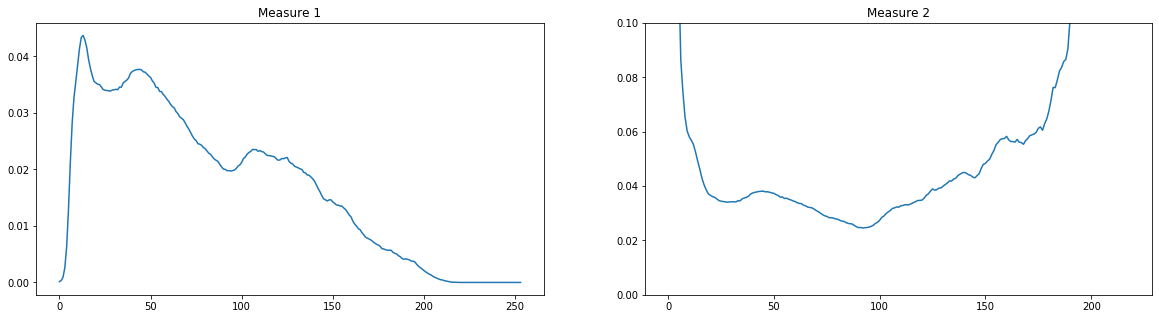

In [20]:
scores_m1 = []
scores_m2 = []

for s in range(1, 255):
    score = discre_measure(T_hv, s)
    scores_m1.append( score[0] )
    scores_m2.append( score[1] )
    
fig, plots = plt.subplots(1,2, figsize = (20, 5))     # subplot with 1 row, 2 columns

# subplot 1
plots[0].plot(scores_m1)
plots[0].set_title('Measure 1')

# subplot 2
plots[1].plot(scores_m2)
plots[1].set_title('Measure 2')
plots[1].set_ylim([0, 0.1])

plt.show()

Now, there are several local minimas. Note that, using a global rule for obtaining the minimum value would possibly lead to a poor segmentation. Hence, we apply a moving window through the array of these scores, to find a value which is minimum in a window span of length $2K$, where $K$ is a choice by the user. Clearly, higher values of $K$ will lead to smaller number of segments, and lower values of $K$ will give higher number of segments. This moving minimum algorithm is implemented in the following piece of code. 

In [21]:
def find_min(scores, k = 1):
    thresholds = []
    for i in range(k, len(scores) - k):
        if min(scores[(i-k):(i+k)]) == scores[i]:
            thresholds.append(i)
    return(thresholds)

Now, we consider the images segmentation for $k = 1, 3, 5, 10, 20$, firstly for Measure 1 and then for Measure 2.

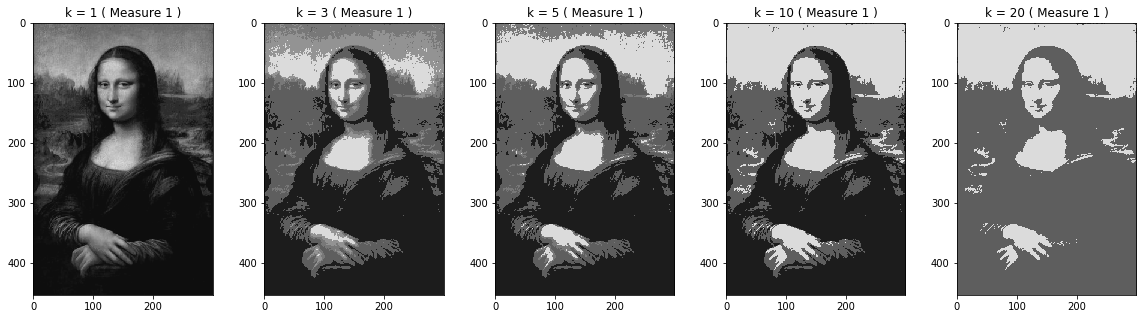

In [26]:
fig, plots = plt.subplots(1,5, figsize = (20, 5))     # subplot with 1 row, 5 columns

# subplot 1
plots[0].imshow( segment(bw_img, find_min(scores_m1, k = 1)) , cmap = 'gray')
plots[0].set_title('k = 1 ( Measure 1 )')

# subplot 2
plots[1].imshow( segment(bw_img, find_min(scores_m1, k = 3)) , cmap = 'gray')
plots[1].set_title('k = 3 ( Measure 1 )')

# subplot 3
plots[2].imshow( segment(bw_img, find_min(scores_m1, k = 5)) , cmap = 'gray')
plots[2].set_title('k = 5 ( Measure 1 )')

# subplot 4
plots[3].imshow( segment(bw_img, find_min(scores_m1, k = 10)) , cmap = 'gray')
plots[3].set_title('k = 10 ( Measure 1 )')

# subplot 4
plots[4].imshow( segment(bw_img, find_min(scores_m1, k = 20)) , cmap = 'gray')
plots[4].set_title('k = 20 ( Measure 1 )')


plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


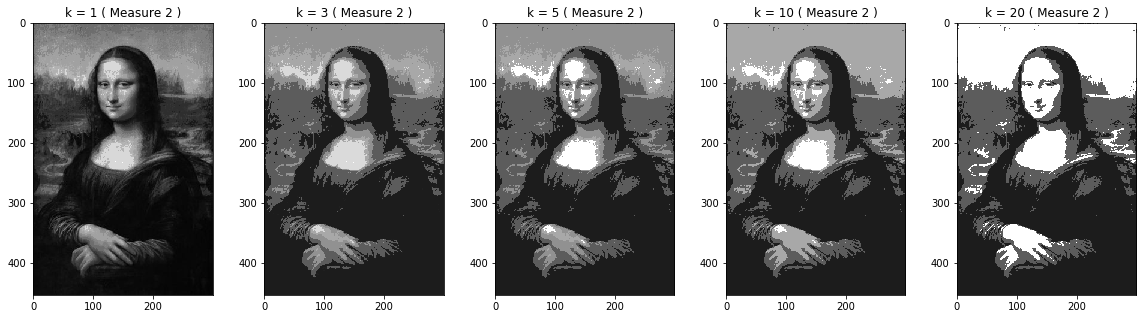

In [27]:
fig, plots = plt.subplots(1,5, figsize = (20, 5))     # subplot with 1 row, 5 columns

# subplot 1
plots[0].imshow( segment(bw_img, find_min(scores_m2, k = 1)) , cmap = 'gray')
plots[0].set_title('k = 1 ( Measure 2 )')

# subplot 2
plots[1].imshow( segment(bw_img, find_min(scores_m2, k = 3)) , cmap = 'gray')
plots[1].set_title('k = 3 ( Measure 2 )')

# subplot 3
plots[2].imshow( segment(bw_img, find_min(scores_m2, k = 5)) , cmap = 'gray')
plots[2].set_title('k = 5 ( Measure 2 )')

# subplot 4
plots[3].imshow( segment(bw_img, find_min(scores_m2, k = 10)) , cmap = 'gray')
plots[3].set_title('k = 10 ( Measure 2 )')

# subplot 4
plots[4].imshow( segment(bw_img, find_min(scores_m2, k = 20)) , cmap = 'gray')
plots[4].set_title('k = 20 ( Measure 2 )')


plt.show()

It looks like for $k = 10$, with measure 1 and for $k = 20$ with meausre 2, we have similar kind of segmentation of the image. However, with measure 2, $k = 20$, the segmentation looks much clearer and ideal, as there are light noises to the background, and almost no noises in definiting the edge of the clothings of the model from the background.

Now, let us inspect how does the thresholds found by this algorithm maps to the co-occurence matrix.

C:\Users\roysu\Anaconda3\envs\python-ml\lib\site-packages\ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in log
  import sys
C:\Users\roysu\Anaconda3\envs\python-ml\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: divide by zero encountered in log
  


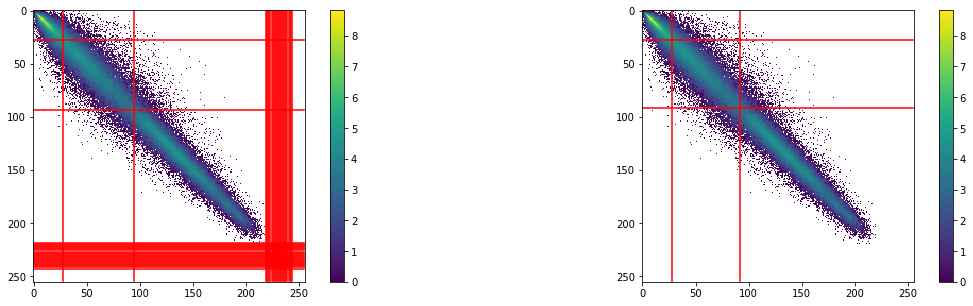

In [34]:
cutoffs1 = np.array(find_min(scores_m1, k = 10))
cutoffs2 = np.array(find_min(scores_m2, k = 20))

fig, plots = plt.subplots(1, 2, figsize = (20, 5))     # subplot with 1 row, 2 columns

# subplot 1
a = plots[0].imshow(np.log(T_hv))   # take logarithm for ease of visualization
fig.colorbar(a, ax = plots[0])
for cut in cutoffs1:
    plots[0].plot( [cut, cut], [255, 0] , "r-")
    plots[0].plot( [255, 0], [cut, cut], "r-")

# subplot 2
b = plots[1].imshow(np.log(T_hv))   # take logarithm for ease of visualization
fig.colorbar(b, ax = plots[1])
for cut in cutoffs2:
    plots[1].plot( [cut, cut], [255, 0] , "r-")
    plots[1].plot( [255, 0], [cut, cut], "r-")

plt.show()

As you can see, there are lots of unnecessary thresholds selected for measure1. However, then two principal thresholds selected by these methods are at about $25$ and at about $95$, which were the thresholds we picked at the very beginning just by looking at the thresholds. Even with the very basic tool such a histogram, and a little subjective evaluation, we could achieve a reasonable amount of segmentation. 

Now, let us try to apply this method on the colour image as well.

In [35]:
T_hv_red = CCM(col_img[:, :, 0], offset = (0, 1)) + CCM(col_img[:, :, 0], offset = (1, 0))
T_hv_green = CCM(col_img[:, :, 1], offset = (0, 1)) + CCM(col_img[:, :, 1], offset = (1, 0))
T_hv_blue = CCM(col_img[:, :, 2], offset = (0, 1)) + CCM(col_img[:, :, 2], offset = (1, 0))

In [41]:
scores_m1 = np.zeros((3, 256))
scores_m2 = np.zeros((3, 256))

for s in range(1, 255):
    score_red = discre_measure(T_hv_red, s)
    score_green = discre_measure(T_hv_green, s)
    score_blue = discre_measure(T_hv_blue, s)
    
    scores_m1[:, s] =  (score_red[0], score_green[0], score_blue[0])
    scores_m2[:, s] =  (score_red[1], score_green[1], score_blue[1])

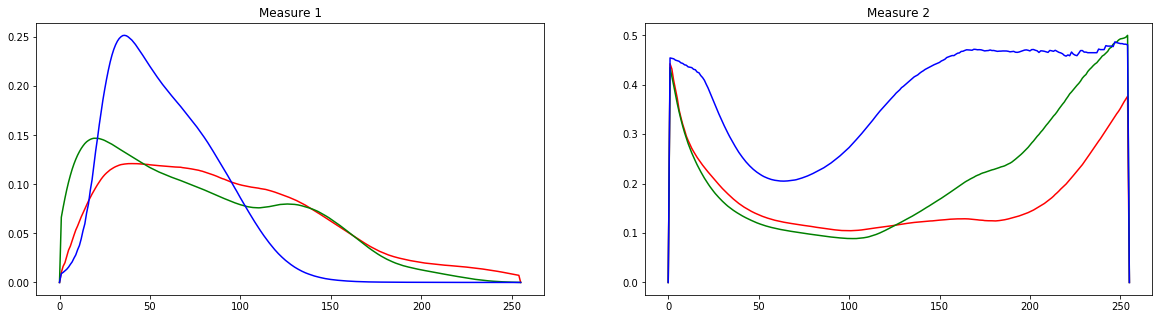

In [79]:
fig, plots = plt.subplots(1, 2, figsize = (20, 5))     # subplot with 1 row, 2 columns

# subplot 1
plots[0].plot(scores_m1[0, :], c = 'r')
plots[0].plot(scores_m1[1, :], c = 'g')
plots[0].plot(scores_m1[2, :], c = 'b')
plots[0].set_title('Measure 1')

# subplot 2
plots[1].plot(scores_m2[0, :], c = 'r')
plots[1].plot(scores_m2[1, :], c = 'g')
plots[1].plot(scores_m2[2, :], c = 'b')
plots[1].set_title('Measure 2')

plt.show()

Note that, for Red and Blue channel, the 2nd measure gives prominent minimums, while for the  Green channel, the prominent minima is obtained by the first measure. Therefore, with some custom tweaking of $K$ and the which measure to choose, you can get a segmentation which is better than methods discussed previously, just because it uses the spatial information, which connects these three channels together.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


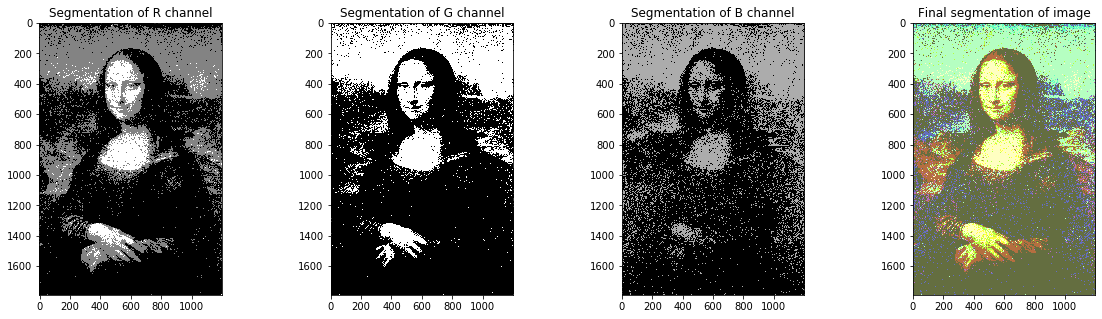

In [77]:
# Exactly same code as before
thres_R = find_min(scores_m2[0, :], k = 30)
thres_G = find_min(scores_m1[1, :], k = 25)
thres_B = find_min(scores_m2[2, :], k = 10)

segment_R = np.expand_dims( segment(col_img[:, :, 0], thres_R) , 2)    # apply segmentation and convert to 3d array
segment_G = np.expand_dims( segment(col_img[:, :, 1], thres_G) , 2)
segment_B = np.expand_dims( segment(col_img[:, :, 2], thres_B) , 2)

segment_img = np.concatenate( (segment_R, segment_G, segment_B), axis = 2)

fig, plots = plt.subplots(1,4, figsize = (20, 5))     # subplot with 1 row, 4 columns

# subplot 1
plots[0].imshow(segment_R[:, :, 0], cmap = 'gray')
plots[0].set_title('Segmentation of R channel')

# subplot 2
plots[1].imshow(segment_G[:, :, 0], cmap = 'gray')
plots[1].set_title('Segmentation of G channel')

# subplot 3
plots[2].imshow(segment_B[:, :, 0], cmap = 'gray')
plots[2].set_title('Segmentation of B channel')

# final image
plots[3].imshow(segment_img)
plots[3].set_title('Final segmentation of image')

plt.show()

As it seems, the final segmented image looks better than the previous ones. Note that, 

* The sky is coloured green, (since the green channel was able to capture that properly)
* The visible first layer of background, which is the valley, is coloured blue, as blue channel properly captures that.
* The visible second layer of background, which constitutes what is possibly iceberg (or some rivers) is captures in the red channel (and hence is of brown colour in the final segmentation).
* The skin of Mona Lisa is capture in red and green channel, and slightly by blue channel, which mixes up to give a different tone for the skin.
* The dark clothing is not captured through any of the channel segmentation, hence remains dark in the final outcome.

The following are some references if you wish to boost up your knowledge and learn subtle details of the algorithms presented above.

## References

1. F. Deravi and S.K. Pal, "Gray Level Thresholding Using Second-order Statistics", Pattern Recogn. Letters, vol. 1, pp.417-422, 1983. [PDF](https://www.isical.ac.in/~sankar/paper/pdf21.pdf).

2. [Wikipedia article Thresholding (image processing).](https://en.wikipedia.org/wiki/Thresholding_(image_processing))

3. [Wikipedia article Otsu's Method](https://en.wikipedia.org/wiki/Otsu%27s_method)

4. [Wikipedia article Image Segmentation](https://en.wikipedia.org/wiki/Image_segmentation)

5.  Linda G. Shapiro and George C. Stockman (2001): “Computer Vision”, pp 279-325, New Jersey, Prentice-Hall, ISBN 0-13-030796-3 [PDF](http://nana.lecturer.pens.ac.id/index_files/referensi/computer_vision/Computer%20Vision.pdf)


*Note: The model, Lisa del Giocondo, was a member of the Gherardini family of Florence and Tuscany, and the wife of wealthy Florentine silk merchant Francesco del Giocondo. The Italian name for the painting, La Gioconda, means 'jocund' ('happy' or 'jovial') or, literally, 'the jocund one', a pun on the feminine form of Lisa's married name, Giocondo. In French, the title La Joconde has the same meaning, i.e. to become happy. ~ Wikipedia*

& Finally, stay safe and keep safe your families, friends and neighbours!